In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
sns.set_palette("pastel")

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
df['customerID'].nunique()

7043

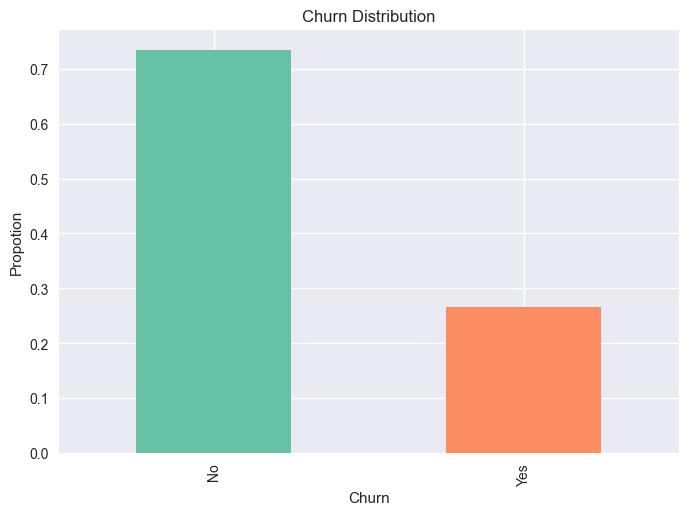

In [6]:
df["Churn"].value_counts(normalize=True).plot(
    kind = 'bar',
    color=['#66c2a5', '#fc8d62']

)
plt.title("Churn Distribution")
plt.ylabel("Propotion")
plt.xlabel("Churn")
plt.show()

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [8]:
df["TotalCharges"].isnull().sum()

0

In [9]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.000,0.0000,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80


In [11]:
df.drop("customerID", axis=1, inplace=True)

In [12]:
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical variables : ", cat_cols)
print("Numerical variables : ", num_cols)

Categorical variables :  ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']
Numerical variables :  ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


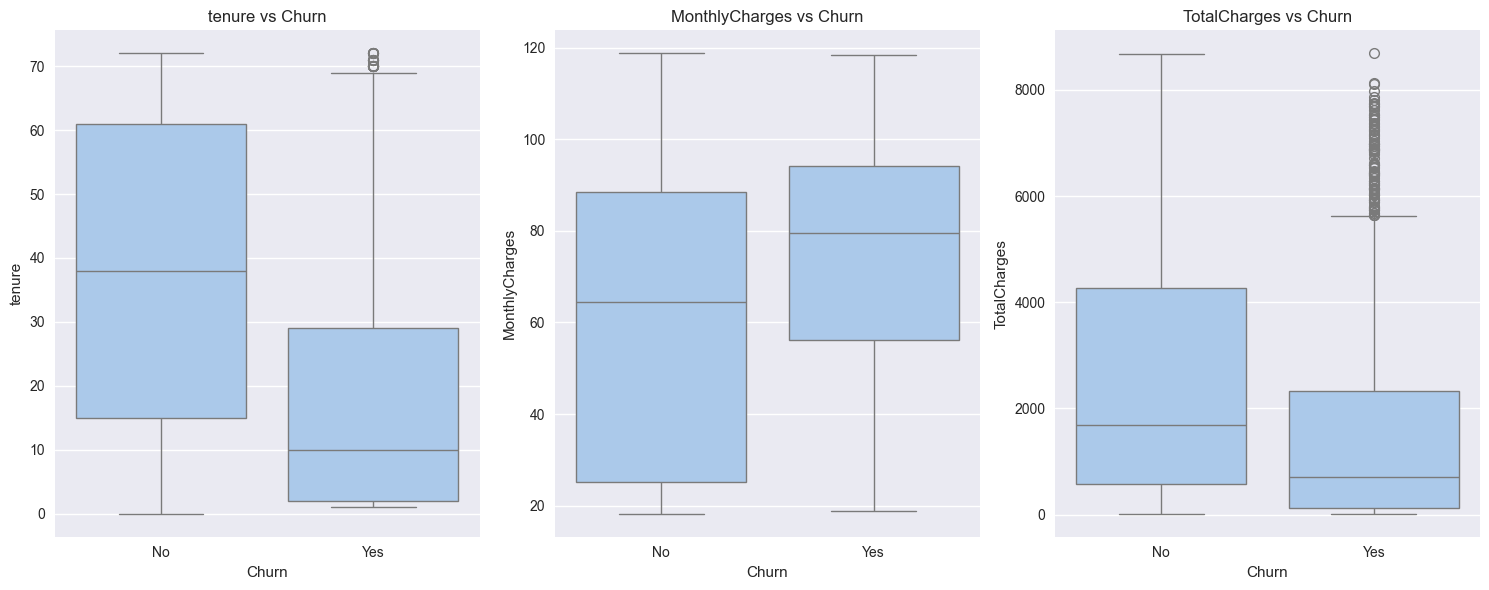

In [13]:
numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]

plt.figure(figsize=(15,6))
for i, feature in enumerate(numeric_features, 1):
    plt.subplot(1,3,i)
    sns.boxplot(x="Churn", y=feature, data=df)
    plt.title(f"{feature} vs Churn")
plt.tight_layout()
plt.show()

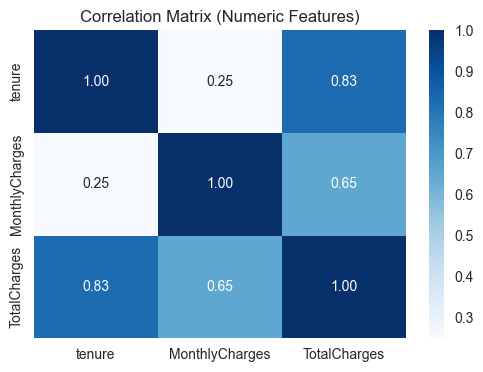

In [14]:
corr = df[["tenure", "MonthlyCharges", "TotalCharges"]].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Matrix (Numeric Features)")
plt.show()

In [15]:
categorical_features = cat_cols
categorical_features.remove("Churn")
categorical_features

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

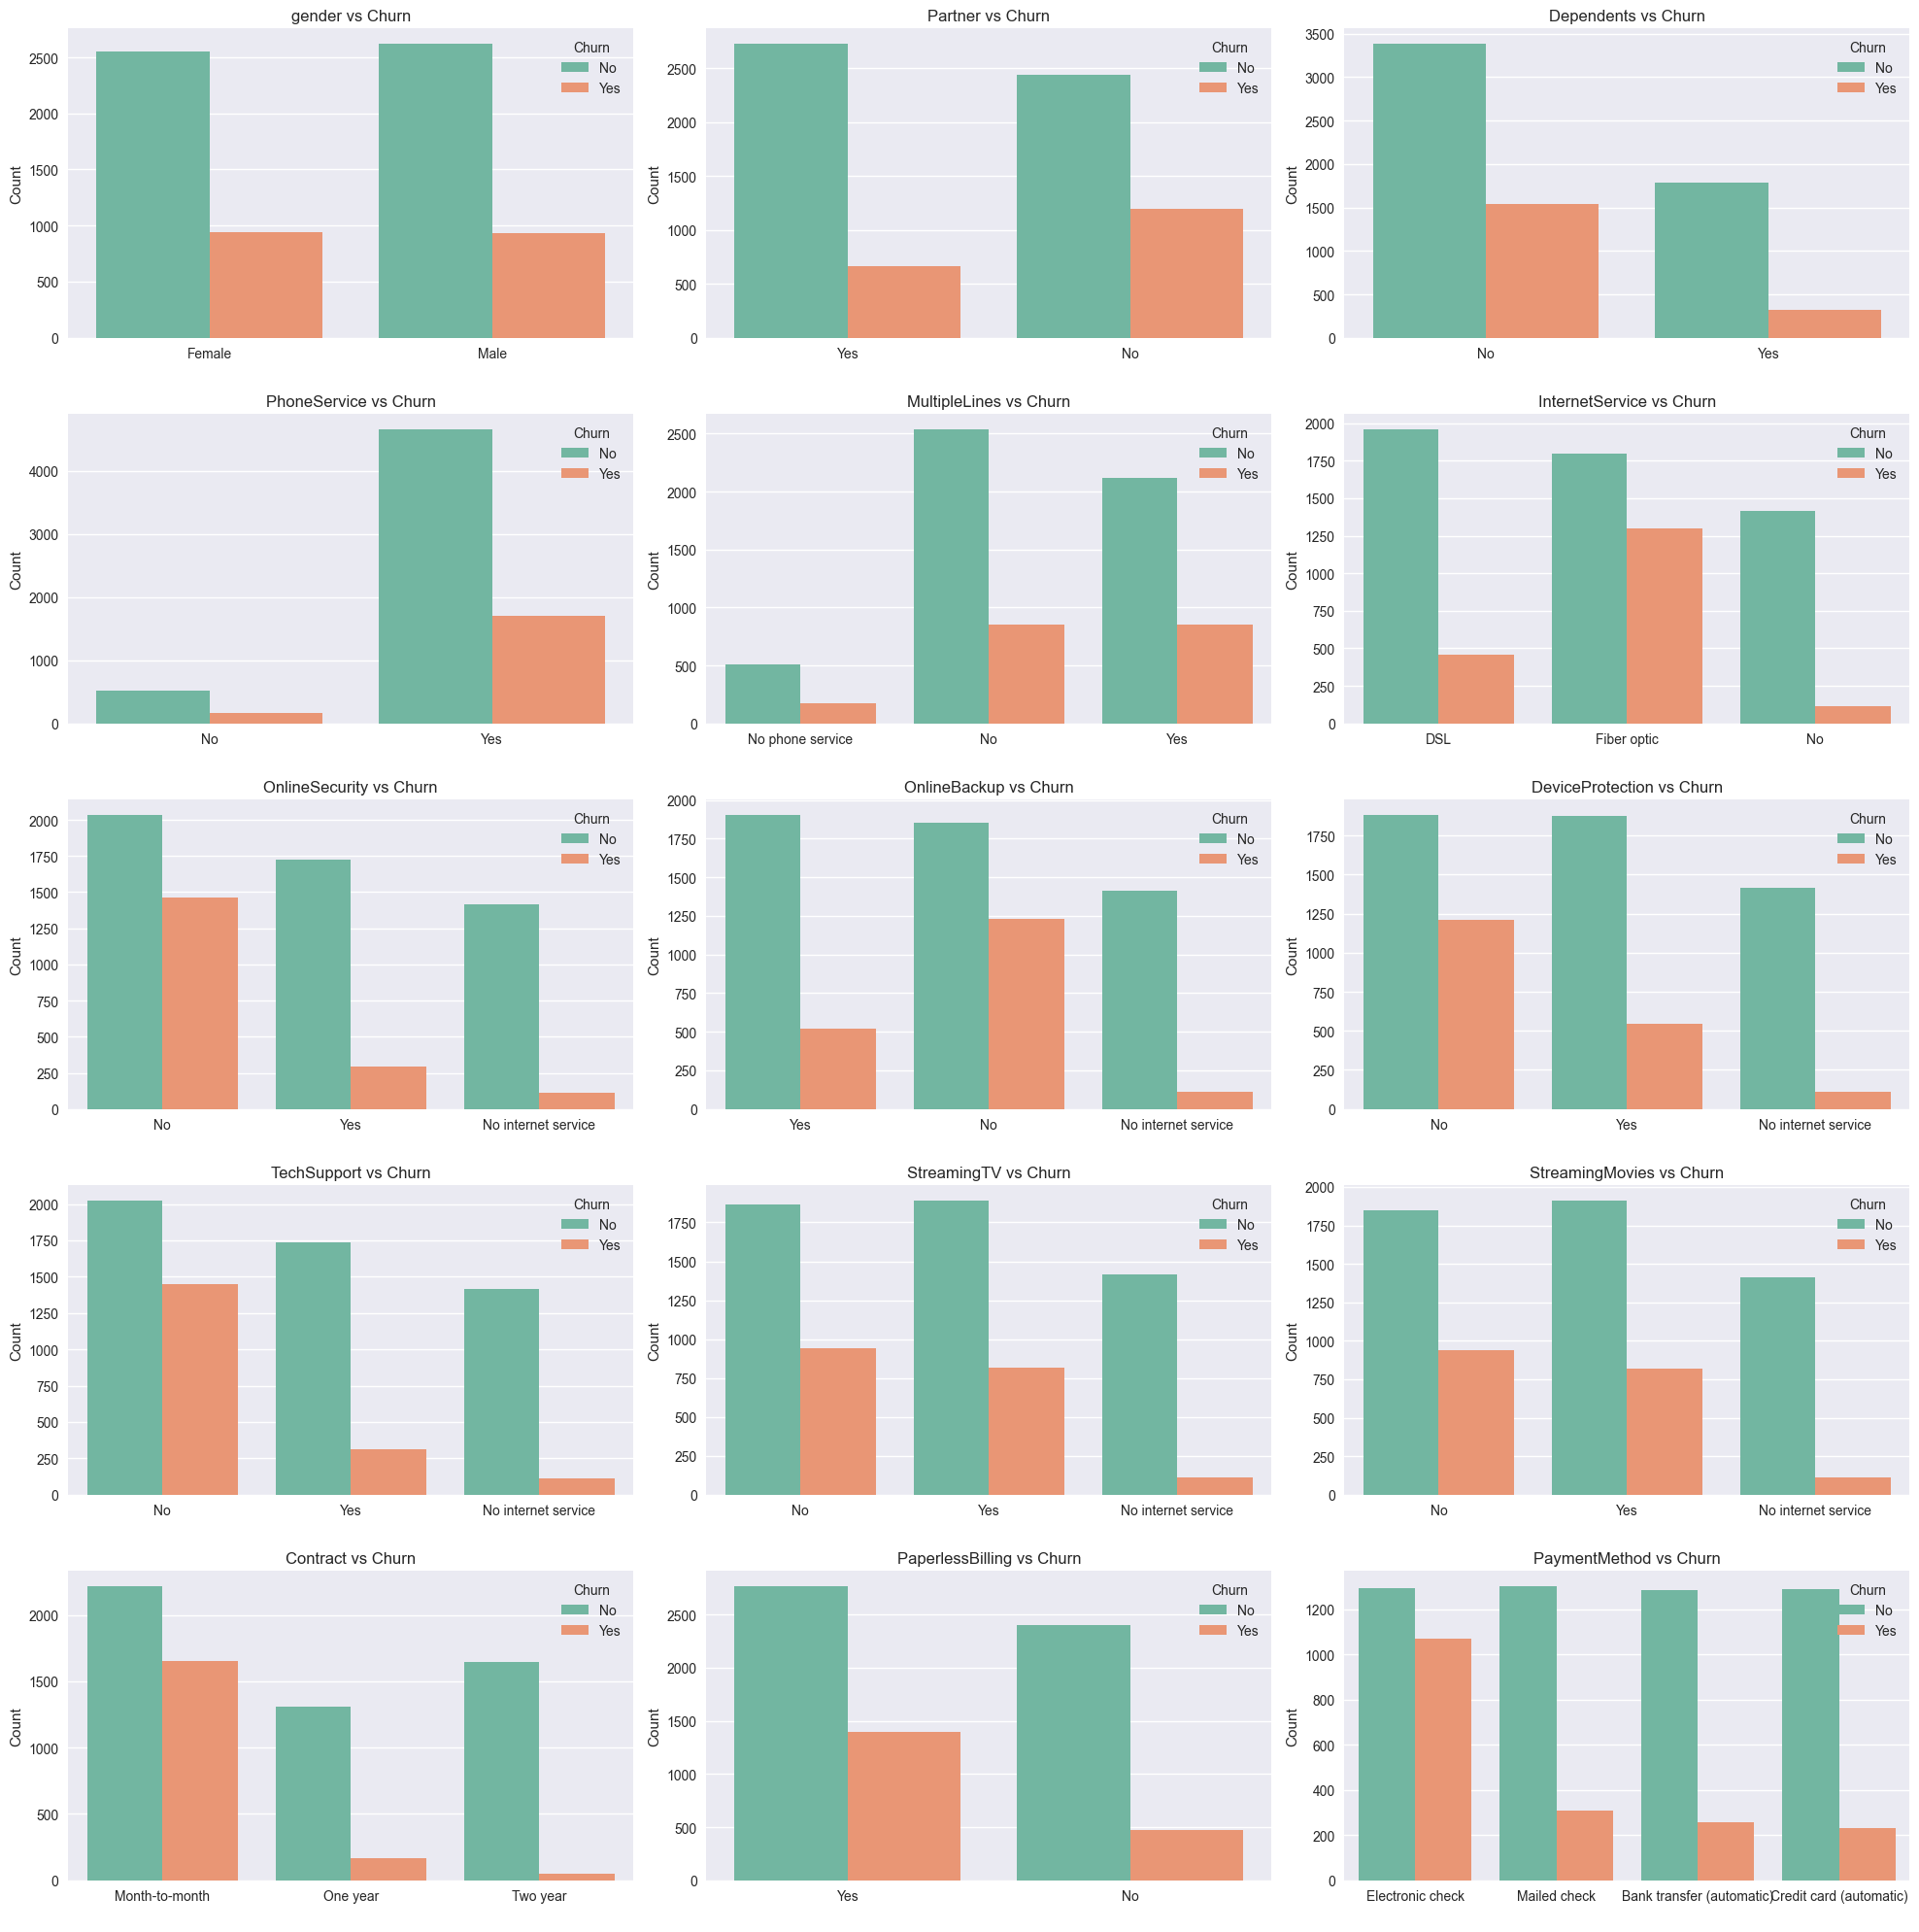

In [22]:
plt.figure(figsize=(20,20))

for i, feature in enumerate(categorical_features, 1):
    plt.subplot(5,3,i)
    sns.countplot(data = df, x = feature, hue = "Churn", palette = "Set2")
    plt.title(f"{feature} vs Churn", fontsize = 12)
    plt.xlabel(" ")
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

| Feature                          | Observation                                                                        |
| -------------------------------- | ---------------------------------------------------------------------------------- |
| **Contract**                     | Customers with *month-to-month* contracts show the highest churn rate.             |
| **OnlineSecurity / TechSupport** | Customers **without** these services are more likely to churn.                     |
| **PaymentMethod**                | Those who pay via *electronic check* tend to churn more frequently.                |
| **PaperlessBilling**             | Customers using paperless billing show a higher churn tendency.                    |
| **InternetService**              | Customers with *fiber optic* internet have a higher churn rate compared to others. |


- Categorical variables such as Contract type, InternetService and optional add-ons (OnlineSecurity, TechSupport) show strong associations with customer churn.
- Customers with month-to-month contracts, fiber optic internet and no additional services are at the highest risk of churn.

In [17]:
def detect_outliers(df, features):
    outlier_indicies = {}

    for feature in features:
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
    
        outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)].index
        outlier_indicies[feature] = outliers
    
        print(f"{feature}: {len(outliers)} outliers detected")

    return outlier_indicies

outliers = detect_outliers(df, numeric_features)

tenure: 0 outliers detected
MonthlyCharges: 0 outliers detected
TotalCharges: 0 outliers detected


* No significal outliers were detected in numerical variables using IQR method.
* The data distribution appears consistent and within expected bussiness ranges